# 00 — Camera lỗ kim và dữ liệu KITTI

Cả dự án xoay quanh một câu hỏi: **từ một khung bao trên ảnh, vật cách camera bao xa?**
Muốn trả lời, trước hết phải biết camera biến một điểm 3D thành một điểm ảnh như thế nào,
và KITTI ghi lại "sự thật" (nhãn, hiệu chuẩn) ra sao. Notebook này xây phần móng đó và
kiểm chứng từng công thức trên chính nhãn KITTI của dự án.

| Mục | Câu hỏi nó trả lời |
|---|---|
| 1. Hệ toạ độ camera | Trục nào là "phía trước", đơn vị gì? |
| 2. Phép chiếu lỗ kim | Điểm $(X, Y, Z)$ rơi vào pixel nào? |
| 3. Ma trận nội tại và ma trận chiếu | Vì sao KITTI cho một ma trận $3\times 4$ tên `P2`? |
| 4. Nhãn KITTI tracking | Mỗi dòng nhãn chứa gì, "khoảng cách thật" lấy ở đâu? |
| 5. Chiếu hộp 3D lên ảnh | Nhãn 3D và nhãn 2D có khớp nhau không? |
| 6. Độ sâu và khoảng cách | Vì sao dự án đo độ sâu $z$ chứ không đo đường chim bay? |
| 7. Mơ hồ tỉ lệ | Vì sao một camera không tự đo được mét? |

Chuỗi notebook:

| Notebook | Chủ đề |
|---|---|
| **00** | camera lỗ kim, KITTI (notebook này) |
| 01 | hai công thức khoảng cách và giới hạn của chúng |
| 02 | đánh giá bộ nhận diện: IoU, ghép khung, precision, recall, AP, mAP, ngưỡng F1 |
| 03 | YOLO26 bên trong: dự đoán dày đặc, NMS, đầu ra một-một, fine-tune |
| 04 | mạng học khoảng cách: hồi quy log, L1, rò rỉ dữ liệu, chọn epoch, ensemble |
| 05 | thống kê cho kết quả: khoảng tin cậy, bootstrap theo cụm, so sánh cặp |
| 06 | đo độ trễ: đồng bộ GPU, luật Amdahl, giới hạn khởi chạy kernel, TensorRT, pipeline |

*Code in số thập phân bằng dấu chấm; phần chữ dùng dấu phẩy.*

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import cv2

from monodist import kitti
from monodist.geometry import iou

ROOT = Path("../data/kitti_tracking")          # labels + calib of the 21 sequences, a few images
plt.rcParams.update({"figure.figsize": (9, 3.2), "figure.dpi": 110})
print("sequences:", len(kitti.SEQUENCES), "| frames:", sum(kitti.FRAMES.values()))

sequences: 21 | frames: 8008


## 1. Hệ toạ độ camera

Đặt gốc toạ độ tại **tâm quang học** của camera (điểm mà mọi tia sáng đi qua trước khi chạm
cảm biến). KITTI dùng quy ước:

- $x$ hướng **sang phải** (nhìn theo hướng camera),
- $y$ hướng **xuống dưới**,
- $z$ hướng **ra phía trước**, dọc trục quang học.

Đơn vị là **mét**. Một vật nằm trước camera có $z > 0$; vật nằm dưới tâm quang học (mặt
đường, bánh xe) có $y > 0$. Chiều $y$ hướng xuống nghe ngược đời, nhưng nó khớp với toạ độ
ảnh: dòng pixel cũng đánh số từ trên xuống.

## 2. Phép chiếu lỗ kim

**Định nghĩa.** Camera lỗ kim là mô hình trong đó mỗi điểm 3D chỉ gửi tới cảm biến đúng một
tia sáng, đi thẳng qua tâm quang học. Cảm biến đặt sau tâm một khoảng $f$ (tiêu cự). Ta
thường vẽ mặt ảnh ở *phía trước* tâm cùng khoảng cách $f$ cho khỏi lộn ngược ảnh; hình học
không đổi.

**Công thức — rút ra từ tam giác đồng dạng.** Nhìn từ trên xuống, điểm $(X, Z)$ và tâm
quang học tạo một tam giác; tia sáng cắt mặt ảnh ở hoành độ $x_{\text{ảnh}}$ cách trục một
khoảng tỉ lệ với $X$. Hai tam giác (lớn: cạnh $X$ và $Z$; nhỏ: cạnh $x_{\text{ảnh}}$ và $f$)
đồng dạng nên

$$\frac{x_{\text{ảnh}}}{f} = \frac{X}{Z} \;\Longrightarrow\; x_{\text{ảnh}} = f\,\frac{X}{Z}.$$

Tương tự theo chiều dọc. Đổi sang pixel: gốc toạ độ pixel nằm ở góc trên trái, còn trục
quang học cắt ảnh ở **điểm chính** $(c_x, c_y)$, nên

$$u = f\,\frac{X}{Z} + c_x, \qquad v = f\,\frac{Y}{Z} + c_y.$$

**Ký hiệu mới**
- $f$: tiêu cự **tính bằng pixel** (tiêu cự vật lý chia kích thước một pixel)
- $(u, v)$: cột và dòng của pixel; $(c_x, c_y)$: điểm chính
- $(X, Y, Z)$: toạ độ điểm 3D trong hệ camera, mét

**Khi nào đúng.** Mô hình bỏ qua méo ống kính (đường thẳng bị cong ở mép ảnh). Ảnh KITTI
đã được **chỉnh méo và chỉnh song song** (rectified) nên mô hình lỗ kim đúng tới mức dưới
một pixel.

**Hệ quả quan trọng nhất cho dự án:** $u, v$ phụ thuộc $X/Z$ và $Y/Z$, tức chỉ phụ thuộc
**hướng** của tia sáng. Mọi đại lượng pixel chia cho $f$ là một **góc** (chính xác hơn là
tan của góc): $\tfrac{u - c_x}{f} = \tfrac{X}{Z}$. Notebook 04 dùng đúng điều này để làm
đặc trưng không phụ thuộc camera.

## 3. Ma trận nội tại và ma trận chiếu

Viết phép chiếu dưới dạng ma trận bằng **toạ độ đồng nhất**: thêm một thành phần 1 vào
cuối vector, rồi "chia cho thành phần cuối" ở bước sau.

$$\begin{pmatrix} u\,Z \\ v\,Z \\ Z \end{pmatrix}
= \underbrace{\begin{pmatrix} f & 0 & c_x \\ 0 & f & c_y \\ 0 & 0 & 1 \end{pmatrix}}_{K}
\begin{pmatrix} X \\ Y \\ Z \end{pmatrix}.$$

Nhân ra: dòng đầu cho $fX + c_x Z$, chia cho $Z$ được đúng $u$ ở mục 2.

KITTI có bốn camera gắn trên một thanh ngang; nhãn 3D được ghi trong hệ toạ độ của
**camera 0**, còn ảnh ta dùng là của **camera 2** (camera màu bên trái). Hai camera song
song, chỉ lệch nhau một đoạn tịnh tiến $t$. Ma trận chiếu $3\times 4$ gộp cả hai bước:

$$P_2 = K\,[\,I \mid t\,], \qquad
\begin{pmatrix} uZ \\ vZ \\ Z \end{pmatrix} = P_2 \begin{pmatrix} X \\ Y \\ Z \\ 1 \end{pmatrix}.$$

**Ký hiệu mới**
- $K$: ma trận nội tại (intrinsics) · $I$: ma trận đơn vị $3\times3$
- $t$: vector tịnh tiến từ hệ camera 0 sang camera 2 · $[\,I\mid t\,]$: ghép $I$ và $t$ thành $3\times4$
- $P_2$: ma trận chiếu của camera 2, là dòng `P2:` trong file `calib`

Vì $P_2 = K[I\mid t]$, cột cuối của $P_2$ là $Kt$, nên $t = K^{-1}\cdot(\text{cột cuối})$.
Kiểm tra trên chuỗi 0000:

In [2]:
P2 = kitti.load_calib(ROOT, "0000")
k = kitti.intrinsics(P2)
np.set_printoptions(precision=4, suppress=True)
print("P2 =\n", P2)
print(f"f = {k['f']:.2f} px, cx = {k['cx']:.1f}, cy = {k['cy']:.1f}")
print("t = K^-1 * last column =", k["t"], "(metres)")
K = P2[:, :3]
print("rebuild P2 from K and t:", np.allclose(np.hstack([K, (K @ k["t"])[:, None]]), P2))

P2 =
 [[721.5377   0.     609.5593  44.8573]
 [  0.     721.5377 172.854    0.2164]
 [  0.       0.       1.       0.0027]]
f = 721.54 px, cx = 609.6, cy = 172.9
t = K^-1 * last column = [ 0.0598 -0.0004  0.0027] (metres)
rebuild P2 from K and t: True


Đọc kết quả:
- $f \approx 721{,}5$ px, điểm chính gần giữa ảnh theo chiều ngang ($c_x \approx 610$ trên
  ảnh rộng 1242) và hơi cao hơn giữa theo chiều dọc ($c_y \approx 173$ trên ảnh cao 375).
- $t_x \approx 0{,}06$ m: một điểm có $X$ trong hệ camera 0 có $X + 0{,}06$ trong hệ camera 2,
  nghĩa là camera 2 đặt lệch khoảng 6 cm so với camera 0. Các thành phần khác gần 0.
- Hàm `kitti.to_camera2` cộng đúng $t$ này; độ sâu dự án dùng là $z$ **trong hệ camera 2**.

**Không phải mọi chuỗi có cùng $f$.** KITTI thu dữ liệu trong nhiều ngày, mỗi ngày hiệu
chuẩn lại:

In [3]:
groups = {}
for s in kitti.SEQUENCES:
    f = round(kitti.intrinsics(kitti.load_calib(ROOT, s))["f"], 2)
    groups.setdefault(f, []).append(s)
for f, seqs in sorted(groups.items()):
    split = {sp for sp, v in kitti.SPLIT.items() for q in seqs if q in v}
    print(f"f = {f:7.2f} px  sequences {' '.join(seqs)}  (splits: {', '.join(sorted(split))})")

f =  707.05 px  sequences 0014 0015 0016 0017  (splits: test, val)
f =  718.34 px  sequences 0018 0019  (splits: train)
f =  718.86 px  sequences 0020  (splits: train)
f =  721.54 px  sequences 0000 0001 0002 0003 0004 0005 0006 0007 0008 0009 0010 0011 0012 0013  (splits: test, train, val)


Bốn giá trị từ 707 đến 722 px, chênh nhau khoảng 2%. Nếu dùng một $f$ chung, mọi khoảng cách
suy ra từ chuỗi 0014–0017 sẽ lệch có hệ thống khoảng 2%. Vì vậy mọi chỗ trong dự án đều đọc
hiệu chuẩn **theo từng chuỗi**.

## 4. Nhãn KITTI tracking

Mỗi chuỗi có một file `label_02/<chuỗi>.txt`, mỗi dòng là **một vật trong một khung hình**:

| Cột | Ý nghĩa |
|---|---|
| `frame`, `track` | số khung; mã vật, giữ nguyên qua các khung (cùng một chiếc xe) |
| `type` | Car, Van, Truck, Pedestrian, Person (người ngồi), Cyclist, Tram, Misc, DontCare |
| `trunc` | bị mép ảnh cắt: 0 không, 1 một phần, 2 nhiều |
| `occ` | bị che: 0 không, 1 một phần, 2 nhiều, 3 không rõ |
| `box` | khung bao 2D trên ảnh camera 2: $x_1, y_1, x_2, y_2$ (pixel) |
| `dim` | kích thước hộp 3D: cao, rộng, dài (mét) |
| `loc` | **tâm đáy** của hộp 3D, trong hệ camera 0 (mét) |
| `ry` | góc quay quanh trục $y$ |

Nhãn 3D được dựng từ **LiDAR** (máy quét laser đo khoảng cách trực tiếp) nên $z$ trong `loc`
là "khoảng cách thật" của dự án. `DontCare` đánh dấu vùng có vật nhưng người gán nhãn bỏ qua
(quá xa, quá nhỏ); notebook 02 giải thích vì sao phải bỏ qua dự đoán rơi vào đó.

In [4]:
lab = kitti.load_labels(ROOT, "0012")
first = lab["frame"] == 0
for i in np.where(first)[0]:
    print(f"track {lab['track'][i]:2d} {lab['type'][i]:10s} trunc {lab['trunc'][i]} occ {lab['occ'][i]} "
          f"box {np.round(lab['box'][i], 1)} dim {np.round(lab['dim'][i], 2)} loc {np.round(lab['loc'][i], 2)}")

types, counts = np.unique(np.concatenate([kitti.load_labels(ROOT, s)["type"] for s in kitti.SEQUENCES]),
                          return_counts=True)
print("\nall 21 sequences:", dict(zip(types, counts)))

track -1 DontCare   trunc -1 occ -1 box [714.2 182.7 762.7 198.2] dim [-1000. -1000. -1000.] loc [-10.  -1.  -1.]
track  0 Cyclist    trunc 0 occ 0 box [554.5 166.4 666.  271.8] dim [1.73 0.62 1.83] loc [-0.06  1.63 12.34]
track  1 Car        trunc 0 occ 0 box [459.6 180.3 566.8 217. ] dim [1.48 1.8  4.31] loc [-4.12  1.83 30.9 ]
track  3 Car        trunc 0 occ 0 box [655.  180.2 688.7 206.9] dim [1.69 1.88 4.5 ] loc [ 4.19  2.2  48.52]



all 21 sequences: {np.str_('Car'): np.int64(27300), np.str_('Cyclist'): np.int64(1938), np.str_('DontCare'): np.int64(18039), np.str_('Misc'): np.int64(793), np.str_('Pedestrian'): np.int64(11470), np.str_('Person'): np.int64(676), np.str_('Tram'): np.int64(595), np.str_('Truck'): np.int64(1189), np.str_('Van'): np.int64(3301)}


Dự án chỉ đo hai lớp có nhiều nhãn nhất: **Car** (27.300 lần xuất hiện) và **Pedestrian**
(11.470). Van và Person (người ngồi) được coi là **lớp lân cận** khi chấm (notebook 02).

## 5. Chiếu hộp 3D lên ảnh

Hộp 3D có 8 đỉnh. `kitti.box_corners` dựng chúng từ `dim`, `loc`, `ry`; `kitti.project` nhân
với $P_2$ rồi chia cho thành phần cuối. Nếu nhãn nhất quán, khung chữ nhật nhỏ nhất bao 8 đỉnh
đã chiếu phải trùng khung 2D của nhãn. Vẽ trên khung 0 của chuỗi 0012:

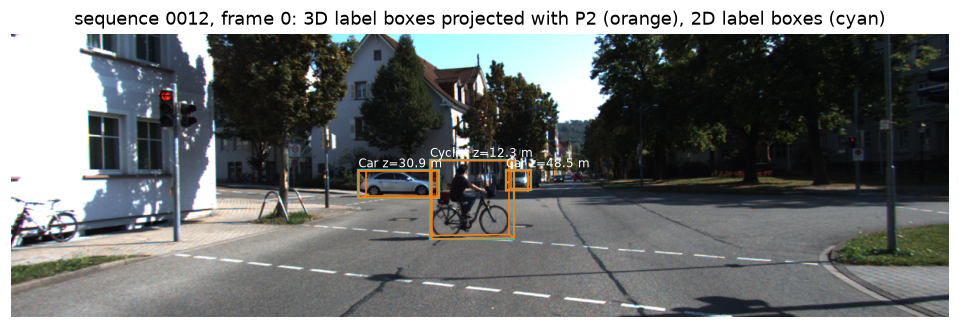

In [5]:
img = cv2.cvtColor(cv2.imread(str(kitti.image_path(ROOT, "0012", 0))), cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.imshow(img)
for i in np.where(first & np.isin(lab["type"], kitti.CLASSES + ("Cyclist",)))[0]:
    uv = kitti.project(kitti.box_corners(lab["dim"][i], lab["loc"][i], lab["ry"][i]), P2 := kitti.load_calib(ROOT, "0012"))
    for a, b in [(0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6), (6, 7), (7, 4), (0, 4), (1, 5), (2, 6), (3, 7)]:
        ax.plot(uv[[a, b], 0], uv[[a, b], 1], color="tab:orange", lw=1)
    x1, y1, x2, y2 = lab["box"][i]
    ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color="tab:cyan", lw=1.5))
    ax.text(x1, y1 - 4, f"{lab['type'][i]} z={kitti.to_camera2(lab['loc'][i:i+1], P2)[0, 2]:.1f} m", color="w", fontsize=8)
ax.set_title("sequence 0012, frame 0: 3D label boxes projected with P2 (orange), 2D label boxes (cyan)")
ax.axis("off"); plt.show()

Kiểm tra định lượng trên **mọi** vật không bị cắt, không bị che của cả 21 chuỗi: tính IoU
(độ trùng khớp, định nghĩa chi tiết ở notebook 02: diện tích giao chia diện tích hợp, từ 0 đến 1)
giữa khung bao của hộp 3D đã chiếu và khung 2D của nhãn.

In [6]:
ious, zs, cls = [], [], []
for s in kitti.SEQUENCES:
    lab_s, P = kitti.load_labels(ROOT, s), kitti.load_calib(ROOT, s)
    m = np.isin(lab_s["type"], kitti.CLASSES) & (lab_s["trunc"] == 0) & (lab_s["occ"] == 0)
    for i in np.where(m)[0]:
        uv = kitti.project(kitti.box_corners(lab_s["dim"][i], lab_s["loc"][i], lab_s["ry"][i]), P)
        ious.append(iou([uv[:, 0].min(), uv[:, 1].min(), uv[:, 0].max(), uv[:, 1].max()], lab_s["box"][i])[0, 0])
        zs.append(lab_s["loc"][i, 2]); cls.append(lab_s["type"][i])
ious, zs, cls = np.array(ious), np.array(zs), np.array(cls)
print(f"{len(ious)} clean objects: median IoU {np.median(ious):.3f}, 5th percentile {np.percentile(ious, 5):.3f}")
for c in kitti.CLASSES:
    for lo, hi in [(0, 10), (10, 20), (20, 40), (40, 100)]:
        m = (zs >= lo) & (zs < hi) & (cls == c)
        if m.any():
            print(f"  {c:10s} z {lo:2d}-{hi:3d} m: n={m.sum():5d}  median IoU {np.median(ious[m]):.3f}")

19083 clean objects: median IoU 0.970, 5th percentile 0.548
  Car        z  0- 10 m: n= 1071  median IoU 0.971
  Car        z 10- 20 m: n= 2773  median IoU 0.975
  Car        z 20- 40 m: n= 4715  median IoU 0.976
  Car        z 40-100 m: n= 3267  median IoU 0.976
  Pedestrian z  0- 10 m: n= 2554  median IoU 0.646
  Pedestrian z 10- 20 m: n= 3112  median IoU 0.681
  Pedestrian z 20- 40 m: n= 1543  median IoU 0.678
  Pedestrian z 40-100 m: n=   48  median IoU 0.676


IoU trung vị **0,97**: nhãn 3D và 2D khớp nhau, nên dùng $z$ làm khoảng cách thật là an toàn.

Tách theo lớp thì thấy rõ: ô tô khớp ở mọi khoảng cách (0,97), còn **người đi bộ chỉ khoảng
0,65–0,68 ở mọi khoảng cách**. Lý do là hình học, không phải lỗi nhãn: hộp 3D của một người rộng
và dài cỡ 0,6–1 m để chứa cả tay chân khi bước, còn khung 2D ôm sát dáng người. Khung chiếu
của hộp 3D vì thế luôn rộng hơn khung nhãn một tỉ lệ gần như cố định. Chiều **cao** của hai
khung vẫn gần nhau, và chiều cao mới là thứ công thức ở notebook 01 dùng. Kiểm chứng (vật xa hơn
10 m, không bị cắt, không bị che):

In [7]:
ratio_h, ratio_w = {c: [] for c in kitti.CLASSES}, {c: [] for c in kitti.CLASSES}
for s in kitti.SEQUENCES:
    lab_s, P = kitti.load_labels(ROOT, s), kitti.load_calib(ROOT, s)
    m = np.isin(lab_s["type"], kitti.CLASSES) & (lab_s["trunc"] == 0) & (lab_s["occ"] == 0) & (lab_s["loc"][:, 2] > 10)
    for i in np.where(m)[0]:
        uv = kitti.project(kitti.box_corners(lab_s["dim"][i], lab_s["loc"][i], lab_s["ry"][i]), P)
        x1, y1, x2, y2 = lab_s["box"][i]
        ratio_h[lab_s["type"][i]].append(np.ptp(uv[:, 1]) / (y2 - y1))
        ratio_w[lab_s["type"][i]].append(np.ptp(uv[:, 0]) / (x2 - x1))
for c in kitti.CLASSES:
    print(f"{c:10s} projected / label box: height {np.median(ratio_h[c]):.3f}, width {np.median(ratio_w[c]):.3f}")

Car        projected / label box: height 0.999, width 0.993
Pedestrian projected / label box: height 0.998, width 1.436


Chiều cao khớp tới 0,2% cho cả hai lớp; chỉ chiều rộng của người đi bộ lệch (1,44 lần). Điều này cũng báo trước notebook 01: khung 2D của ô tô bao **cả chiều dài
xe**, chứ không chỉ mặt đứng gần nhất.

## 6. Độ sâu $z$ và khoảng cách đường chim bay

"Khoảng cách" có hai nghĩa:
- **độ sâu** $z$: hình chiếu lên trục quang học;
- **khoảng cách Euclid** $d = \sqrt{x^2 + y^2 + z^2}$: đường chim bay.

Dự án dùng $z$ vì cả hai công thức (notebook 01) đều suy ra từ $u = fX/Z + c_x$, trong đó
$Z$ là độ sâu. Chênh lệch giữa hai đại lượng: $d/z = \sqrt{1 + (x/z)^2 + (y/z)^2}$, tức
chỉ phụ thuộc góc lệch khỏi trục.

In [8]:
loc = np.concatenate([kitti.to_camera2(kitti.load_labels(ROOT, s)["loc"][np.isin(kitti.load_labels(ROOT, s)["type"], kitti.CLASSES)],
                                       kitti.load_calib(ROOT, s)) for s in kitti.SEQUENCES])
loc = loc[loc[:, 2] > 2]
ratio = np.linalg.norm(loc, axis=1) / loc[:, 2]
print(f"d / z: median {np.median(ratio):.4f}, 90th percentile {np.percentile(ratio, 90):.4f}, max {ratio.max():.3f}")
half_fov = np.degrees(np.arctan(1242 / 2 / 721.5))
print(f"half horizontal field of view: {half_fov:.1f} deg -> d/z at the image edge = {1 / np.cos(np.radians(half_fov)):.3f}")

d / z: median 1.0341, 90th percentile 1.2448, max 2.267
half horizontal field of view: 40.7 deg -> d/z at the image edge = 1.319


Với phần lớn vật, $d$ và $z$ chênh dưới vài phần trăm; ở mép ảnh (góc nửa trường nhìn
khoảng 40°) chênh tới 30%. Chọn một định nghĩa và giữ nhất quán quan trọng hơn chọn định
nghĩa nào; dự án chọn $z$.

## 7. Mơ hồ tỉ lệ: vì sao một camera không tự đo được mét

Nhân mọi toạ độ của cảnh với cùng một số $s > 0$: $(X, Y, Z) \to (sX, sY, sZ)$. Khi đó
$u = f\,\frac{sX}{sZ} + c_x = f\,\frac{X}{Z} + c_x$: **ảnh không đổi**. Một chiếc xe thật cao
1,5 m ở 20 m và một mô hình xe cao 0,15 m ở 2 m cho cùng một ảnh. Kiểm chứng bằng số:

In [9]:
corners = kitti.box_corners(lab["dim"][2], lab["loc"][2], lab["ry"][2])
P2 = kitti.load_calib(ROOT, "0012")
Pn = np.hstack([P2[:, :3], np.zeros((3, 1))])     # drop the 6 cm offset so the scene scales around camera 2 itself
for s in (1.0, 0.1, 3.0):
    uv = kitti.project(corners * s, Pn)
    print(f"scale {s:4.1f}: first corner at pixel {np.round(uv[0], 3)}, depth {corners[0, 2] * s:6.2f} m")

scale  1.0: first corner at pixel [565.469 214.365], depth  31.75 m
scale  0.1: first corner at pixel [565.469 214.365], depth   3.18 m
scale  3.0: first corner at pixel [565.469 214.365], depth  95.25 m


Pixel giống hệt nhau ở mọi tỉ lệ. Muốn ra mét phải thêm **thông tin ngoài ảnh**, và ba
phương pháp của dự án chính là ba cách thêm thông tin đó:

| Phương pháp | Thông tin thêm vào |
|---|---|
| Kích thước đã biết | chiều cao thật trung bình của lớp vật |
| Mặt phẳng sàn | camera cao bao nhiêu so với mặt đường phẳng |
| Mạng học khoảng cách | quy luật học từ hàng chục nghìn ví dụ có LiDAR |

## Tóm tắt

- Phép chiếu lỗ kim: $u = fX/Z + c_x$, $v = fY/Z + c_y$; pixel chia cho $f$ là góc.
- KITTI cho $P_2 = K[I\mid t]$; nhãn 3D ở hệ camera 0, ảnh ở camera 2, lệch nhau 6 cm.
- Có **4 bộ hiệu chuẩn** ($f$ từ 707 đến 722 px), nên phải đọc theo từng chuỗi.
- Nhãn 3D chiếu lên khớp nhãn 2D với IoU trung vị 0,97; độ sâu $z$ từ LiDAR là khoảng cách thật.
- Một camera chỉ cho hướng, không cho tỉ lệ; ba phương pháp đo khoảng cách là ba cách bổ sung tỉ lệ.